In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

data_dir = Path("../data")
conn = sqlite3.connect(data_dir / "olist.db")

files = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

for table, file in files.items():
    df = pd.read_csv(data_dir / file)
    df.to_sql(table, conn, if_exists="replace", index=False)
    print(f"{table}: {len(df):,} rows loaded")

orders: 99,441 rows loaded
customers: 99,441 rows loaded
order_items: 112,650 rows loaded
payments: 103,886 rows loaded
reviews: 99,224 rows loaded
products: 32,951 rows loaded
sellers: 3,095 rows loaded
category_translation: 71 rows loaded


In [2]:
query = """
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name) AS category,
    ROUND(SUM(oi.price), 2) AS revenue,
    COUNT(DISTINCT oi.order_id) AS orders
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY revenue DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,category,revenue,orders
0,health_beauty,1233131.72,8647
1,watches_gifts,1166176.98,5495
2,bed_bath_table,1023434.76,9272
3,sports_leisure,954852.55,7530
4,computers_accessories,888724.61,6530
5,furniture_decor,711927.69,6307
6,housewares,615628.69,5743
7,cool_stuff,610204.10,3559
8,auto,578966.65,3810
9,toys,471286.48,3804


Top 10 categories = 62.4% of total revenue


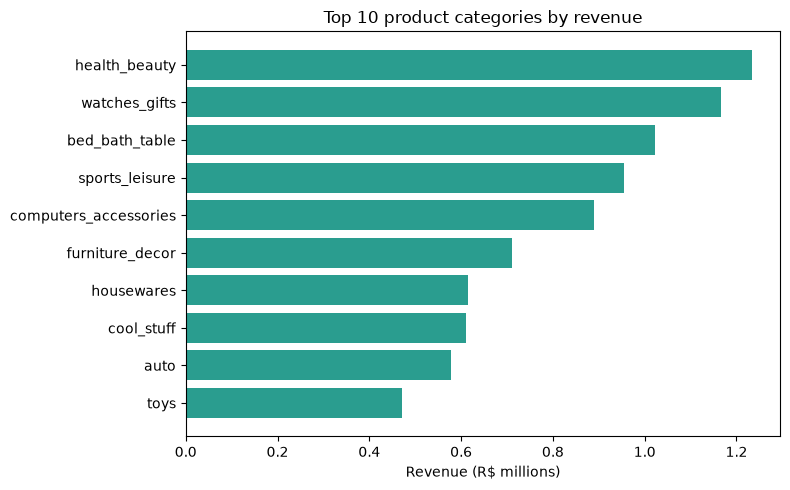

In [3]:
import matplotlib.pyplot as plt

top10 = pd.read_sql(query, conn)

total = pd.read_sql("""
    SELECT SUM(oi.price) AS total
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
""", conn)["total"][0]
print(f"Top 10 categories = {top10['revenue'].sum() / total:.1%} of total revenue")

plot_df = top10.sort_values("revenue")
plt.figure(figsize=(8, 5))
plt.barh(plot_df["category"], plot_df["revenue"] / 1e6, color="#2a9d8f")
plt.xlabel("Revenue (R$ millions)")
plt.title("Top 10 product categories by revenue")
plt.tight_layout()
plt.savefig("../dashboard/top_categories.png", dpi=150)
plt.show()